In [74]:
pip install --upgrade xgboost

In [1]:
!jupyter nbconvert --to html Hate_Speech_Urdu_VVD_21.ipynb

[NbConvertApp] Converting notebook Hate_Speech_Urdu_VVD_21.ipynb to html
Traceback (most recent call last):
  File "C:\Users\Leverage\anaconda3\Scripts\jupyter-nbconvert-script.py", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "C:\Users\Leverage\anaconda3\Lib\site-packages\jupyter_core\application.py", line 283, in launch_instance
    super().launch_instance(argv=argv, **kwargs)
  File "C:\Users\Leverage\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\Leverage\anaconda3\Lib\site-packages\nbconvert\nbconvertapp.py", line 412, in start
    self.convert_notebooks()
  File "C:\Users\Leverage\anaconda3\Lib\site-packages\nbconvert\nbconvertapp.py", line 590, in convert_notebooks
    self.convert_single_notebook(notebook_filename)
  File "C:\Users\Leverage\anaconda3\Lib\site-packages\nbconvert\nbconvertapp.py", line 556, in convert_single_notebook
    output, resources = self.export_single_not

In [75]:
import sklearn
import xgboost as xgb

print("scikit-learn version:", sklearn.__version__)
print("XGBoost version:", xgb.__version__)

scikit-learn version: 1.6.1
XGBoost version: 2.1.3


In [76]:
pip install --upgrade scikit-learn

In [77]:
pip list --outdated

Package                  Version      Latest       Type
------------------------ ------------ ------------ -----
absl-py                  1.4.0        2.1.0        wheel
accelerate               1.2.1        1.3.0        wheel
albucore                 0.0.19       0.0.23       wheel
albumentations           1.4.20       2.0.1        wheel
anyio                    3.7.1        4.8.0        wheel
astropy                  6.1.7        7.0.0        wheel
atpublic                 4.1.0        5.1          wheel
blis                     0.7.11       1.2.0        wheel
cryptography             43.0.3       44.0.0       wheel
cuda-python              12.2.1       12.8.0       wheel
cudf-cu12                24.10.1      24.12.0      wheel
cupy-cuda12x             12.2.0       13.3.0       wheel
dask                     2024.10.0    2025.1.0     wheel
db-dtypes                1.3.1        1.4.0        wheel
dbus-python              1.2.18       1.3.2        sdist
debugpy                  1.8.0  

In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from gensim.models import Word2Vec
from transformers import XLMRobertaTokenizer, XLMRobertaForSequenceClassification
from transformers import Trainer, TrainingArguments
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [3]:
!pip install odfpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 19.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for odfpy: filename=odfpy-1.4.1-py2.py3-none-any.whl size=160672 sha256=344f02db743cf9acf2c284fa81caf4eca2bc5ef3ec78437863cbed5fd16c0c19
  Stored in directory: /root/.cache/pip/wheels/d6/1d/c8/8c29be1d73ca42d15977c75193d9f39a98499413c2838ac54c
Successfully built odfpy


In [4]:
# Step 2: Load and Inspect Dataset
data = pd.read_excel('/content/3.5K_Clean_Violent Views Detection in Urdu Tweets.xlsx')

print(data.head())


   index                                              tweet  label
0      1  یے وقت ہے بلوچستان کو ٹھیک کرنے کا۔جو جو سردار...      1
1      2  یوں معلوم ہوتا ہے کہ یہ ایک حکومت کا مظاہرین پ...      0
2      3  یوں کھوکھلی ہنسی نہ ہنسا کرو جو دل پہ بوجھ ہے ...      0
3      4  یوسف رضا گیلانی کی بے بسی ایک ملک میں پھانسی گ...      0
4      5  یورپی یونین کو منہ توڑ جواب دینے کیلئے کم از ک...      0


# Data Analyzing & Visualization


<ipython-input-5-19b56bafb07f>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=data, palette="coolwarm")


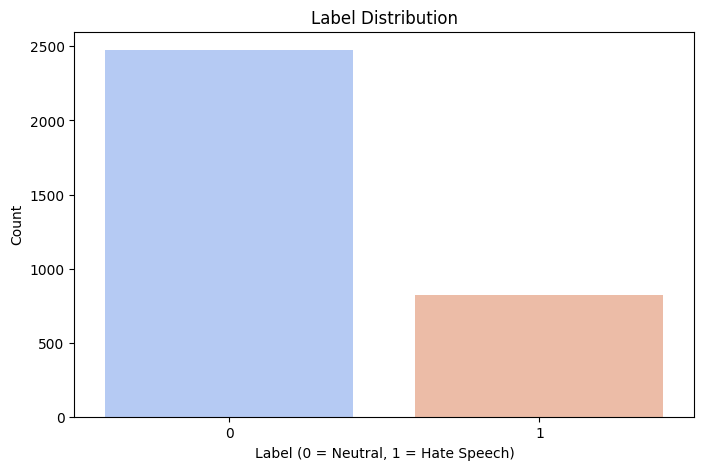

Missing Values: index    0
tweet    0
label    0
dtype: int64


In [5]:
# Visualize the distribution of labels
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=data, palette="coolwarm")
plt.title("Label Distribution")
plt.xlabel("Label (0 = Neutral, 1 = Hate Speech)")
plt.ylabel("Count")
plt.show()

# Check for missing values
print("Missing Values:", data.isnull().sum())


   index                                              tweet  label  \
0      1  یے وقت ہے بلوچستان کو ٹھیک کرنے کا۔جو جو سردار...      1   
1      2  یوں معلوم ہوتا ہے کہ یہ ایک حکومت کا مظاہرین پ...      0   
2      3  یوں کھوکھلی ہنسی نہ ہنسا کرو جو دل پہ بوجھ ہے ...      0   
3      4  یوسف رضا گیلانی کی بے بسی ایک ملک میں پھانسی گ...      0   
4      5  یورپی یونین کو منہ توڑ جواب دینے کیلئے کم از ک...      0   

                                       cleaned_tweet  
0  یے وقت ہے بلوچستان کو ٹھیک کرنے کاجو جو سردار ...  
1  یوں معلوم ہوتا ہے کہ یہ ایک حکومت کا مظاہرین پ...  
2  یوں کھوکھلی ہنسی نہ ہنسا کرو جو دل پہ بوجھ ہے ...  
3  یوسف رضا گیلانی کی بے بسی ایک ملک میں پھانسی گ...  
4  یورپی یونین کو منہ توڑ جواب دینے کیلئے کم از ک...  
label
0    2475
1     822
Name: count, dtype: int64


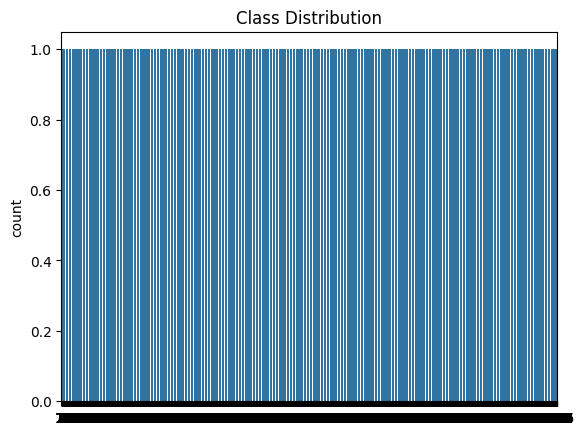

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


# Display first few rows
print(data.head())

# Check data distribution
print(data['label'].value_counts())

# Plot data distribution
sns.countplot(data['label'])
plt.title("Class Distribution")
plt.show()


# Preprocessing using NLP

In [6]:
!pip install urduhack

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.5/105.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.8/82.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 9.2 MB/s eta 0:00:00
  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.4.1
    Uninstalling typeguard-4.4.1:
      Successfully uninstalled typeguard-4.4.1
  Attempting uninstall: Click
    Found existing installation: click 8.1.8
    Uninstalling click-8.1.8:
      Successfully uninstalled click-8.1.8
  Attempting uninstall: tensorflow-datasets
    Found existing installation: tensorflow-datasets 4.9.7
    Uninstalling tensorflow-datasets-4.9.7:
      Successfully uninstalled tensorflow-datasets-4.9.7
ERROR: pip's dependency resolver does not currently take into account all the packages t

In [13]:
!pip install tensorflow==2.13.0
!pip install tensorflow-addons==0.19.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 524.2/524.2 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.8/440.8 kB 30.8 MB/s eta 0:00:00
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.12.2
    Uninstalling typing_extensions-4.12.2:
      Successfully uninstalled typing_extensions-4.12.2
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: keras
    Found existing installation: keras 3.5.0
    Uninstalling keras-3.5.0:
      Successfully uninstalled keras-3.5.0
  Attempting uninstall: gast
    Found existing installation: gast 0.6.0
    Uninstalling gast-0.6.0:
      

ERROR: Could not find a version that satisfies the requirement tensorflow-addons==0.19.0 (from versions: 0.20.0, 0.21.0, 0.22.0, 0.23.0)
ERROR: No matching distribution found for tensorflow-addons==0.19.0


In [6]:
!pip install urduhack --upgrade


In [8]:
!pip install urduhack[full] #Installing urduhack with all required resources, including stop words

In [14]:
pip install urduhack==1.0.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.5/99.5 kB 2.9 MB/s eta 0:00:00
  Attempting uninstall: urduhack
    Found existing installation: urduhack 1.1.1
    Uninstalling urduhack-1.1.1:
      Successfully uninstalled urduhack-1.1.1


In [10]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer

# Text preprocessing function
def preprocess_text(text):
    # Remove special characters and punctuations
    text = re.sub(r'[^\w\s]', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply preprocessing
data['cleaned_tweet'] = data['tweet'].apply(preprocess_text)

# Split dataset
X = data['cleaned_tweet']
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


#EDA

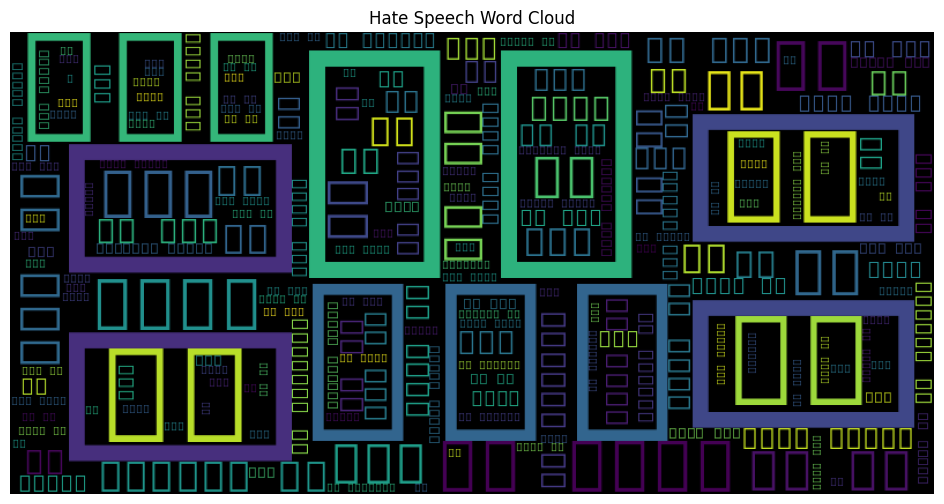

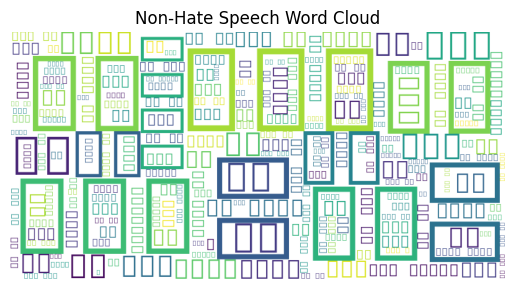

In [11]:
from wordcloud import WordCloud

# Generate word cloud for hate speech and non-hate speech
hate_speech = " ".join(data[data['label'] == 1]['cleaned_tweet'])
non_hate_speech = " ".join(data[data['label'] == 0]['cleaned_tweet'])

plt.figure(figsize=(12, 6))
wc = WordCloud(width=800, height=400, background_color='black').generate(hate_speech)
plt.imshow(wc)
plt.title("Hate Speech Word Cloud")
plt.axis("off")
plt.show()

wc = WordCloud(width=800, height=400, background_color='white').generate(non_hate_speech)
plt.imshow(wc)
plt.title("Non-Hate Speech Word Cloud")
plt.axis("off")
plt.show()


# Feature extraction word & sentence lvl

In [12]:
# Word-Level Features using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_word_vec = vectorizer.fit_transform(X_train)
X_test_word_vec = vectorizer.transform(X_test)

# Sentence-Level Features using SentenceTransformer
sentence_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
X_train_sentence_vec = sentence_model.encode(X_train.tolist())
X_test_sentence_vec = sentence_model.encode(X_test.tolist())

# Combine Word-Level and Sentence-Level Features
X_train_combined = np.hstack((X_train_word_vec.toarray(), X_train_sentence_vec))
X_test_combined = np.hstack((X_test_word_vec.toarray(), X_test_sentence_vec))


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/4.12k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

#Algorithms Implementation

Naive Bayes

In [20]:
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')
nltk.download('punkt_tab') # Download the punkt_tab resource for word tokenization

from nltk.tokenize import word_tokenize

def calculate_word_level_accuracy(X_test, y_test, y_pred):
    total_words = 0
    correct_words = 0

    for i, sentence in enumerate(X_test):
        # Tokenize the sentence into words
        words = word_tokenize(sentence)
        total_words += len(words)

        # If the sentence is classified correctly, count all its words as correct
        if y_test.iloc[i] == y_pred[i]:
            correct_words += len(words)

    # Word-level accuracy
    return correct_words / total_words

# Example: Word-level accuracy for Naive Bayes
word_level_accuracy_nb = calculate_word_level_accuracy(X_test, y_test, y_pred_nb)
print(f"Word-Level Accuracy (Naive Bayes): {word_level_accuracy_nb}")

# Sentence-Level Accuracy (already in code)
sentence_level_accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Sentence-Level Accuracy (Naive Bayes): {sentence_level_accuracy_nb}")


Word-Level Accuracy (Naive Bayes): 0.8537906137184116
Sentence-Level Accuracy (Naive Bayes): 0.8454545454545455


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


RF

In [21]:
from sklearn.ensemble import RandomForestClassifier

# Train model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_word_vec, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test_word_vec)

# Evaluate Sentence-Level Accuracy
sentence_level_accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Sentence-Level Accuracy (Random Forest): {sentence_level_accuracy_rf}")

# Word-Level Accuracy
word_level_accuracy_rf = calculate_word_level_accuracy(X_test, y_test, y_pred_rf)
print(f"Word-Level Accuracy (Random Forest): {word_level_accuracy_rf}")


Sentence-Level Accuracy (Random Forest): 0.8848484848484849
Word-Level Accuracy (Random Forest): 0.8957882069795428


SVM

In [22]:
from sklearn.svm import SVC

# Train model
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_word_vec, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test_word_vec)

# Evaluate Sentence-Level Accuracy
sentence_level_accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Sentence-Level Accuracy (SVM): {sentence_level_accuracy_svm}")

# Word-Level Accuracy
word_level_accuracy_svm = calculate_word_level_accuracy(X_test, y_test, y_pred_svm)
print(f"Word-Level Accuracy (SVM): {word_level_accuracy_svm}")


Sentence-Level Accuracy (SVM): 0.8893939393939394
Word-Level Accuracy (SVM): 0.8960689931809065


Logistic Regression

In [23]:
from sklearn.linear_model import LogisticRegression

# Train model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_word_vec, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test_word_vec)

# Evaluate Sentence-Level Accuracy
sentence_level_accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Sentence-Level Accuracy (Logistic Regression): {sentence_level_accuracy_lr}")

# Word-Level Accuracy
word_level_accuracy_lr = calculate_word_level_accuracy(X_test, y_test, y_pred_lr)
print(f"Word-Level Accuracy (Logistic Regression): {word_level_accuracy_lr}")


Sentence-Level Accuracy (Logistic Regression): 0.8696969696969697
Word-Level Accuracy (Logistic Regression): 0.8726835138387485


In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

# Define parameter grids for each model
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

param_grid_lr = {
    'C': [0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

# Perform GridSearchCV for Random Forest (Word-Level Features)
print("GridSearchCV for Random Forest (Word-Level Features)")
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy')
grid_search_rf.fit(X_train_word_vec, y_train)
print("Best parameters for Random Forest (Word-Level):", grid_search_rf.best_params_)
print("Best score for Random Forest (Word-Level):", grid_search_rf.best_score_)
y_pred_rf_word = grid_search_rf.predict(X_test_word_vec)
print(classification_report(y_test, y_pred_rf_word))
print("Word-Level Accuracy (Random Forest):", accuracy_score(y_test, y_pred_rf_word))

# Perform GridSearchCV for Random Forest (Sentence-Level Features)
print("\nGridSearchCV for Random Forest (Sentence-Level Features)")
grid_search_rf.fit(X_train_sentence_vec, y_train)
print("Best parameters for Random Forest (Sentence-Level):", grid_search_rf.best_params_)
print("Best score for Random Forest (Sentence-Level):", grid_search_rf.best_score_)
y_pred_rf_sentence = grid_search_rf.predict(X_test_sentence_vec)
print(classification_report(y_test, y_pred_rf_sentence))
print("Sentence-Level Accuracy (Random Forest):", accuracy_score(y_test, y_pred_rf_sentence))

# Perform GridSearchCV for SVM (Word-Level Features)
print("\nGridSearchCV for SVM (Word-Level Features)")
grid_search_svm = GridSearchCV(SVC(random_state=42), param_grid_svm, cv=5, scoring='accuracy')
grid_search_svm.fit(X_train_word_vec, y_train)
print("Best parameters for SVM (Word-Level):", grid_search_svm.best_params_)
print("Best score for SVM (Word-Level):", grid_search_svm.best_score_)
y_pred_svm_word = grid_search_svm.predict(X_test_word_vec)
print(classification_report(y_test, y_pred_svm_word))
print("Word-Level Accuracy (SVM):", accuracy_score(y_test, y_pred_svm_word))

# Perform GridSearchCV for SVM (Sentence-Level Features)
print("\nGridSearchCV for SVM (Sentence-Level Features)")
grid_search_svm.fit(X_train_sentence_vec, y_train)
print("Best parameters for SVM (Sentence-Level):", grid_search_svm.best_params_)
print("Best score for SVM (Sentence-Level):", grid_search_svm.best_score_)
y_pred_svm_sentence = grid_search_svm.predict(X_test_sentence_vec)
print(classification_report(y_test, y_pred_svm_sentence))
print("Sentence-Level Accuracy (SVM):", accuracy_score(y_test, y_pred_svm_sentence))

# Perform GridSearchCV for Logistic Regression (Word-Level Features)
print("\nGridSearchCV for Logistic Regression (Word-Level Features)")
grid_search_lr = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000), param_grid_lr, cv=5, scoring='accuracy')
grid_search_lr.fit(X_train_word_vec, y_train)
print("Best parameters for Logistic Regression (Word-Level):", grid_search_lr.best_params_)
print("Best score for Logistic Regression (Word-Level):", grid_search_lr.best_score_)
y_pred_lr_word = grid_search_lr.predict(X_test_word_vec)
print(classification_report(y_test, y_pred_lr_word))
print("Word-Level Accuracy (Logistic Regression):", accuracy_score(y_test, y_pred_lr_word))

# Perform GridSearchCV for Logistic Regression (Sentence-Level Features)
print("\nGridSearchCV for Logistic Regression (Sentence-Level Features)")
grid_search_lr.fit(X_train_sentence_vec, y_train)
print("Best parameters for Logistic Regression (Sentence-Level):", grid_search_lr.best_params_)
print("Best score for Logistic Regression (Sentence-Level):", grid_search_lr.best_score_)
y_pred_lr_sentence = grid_search_lr.predict(X_test_sentence_vec)
print(classification_report(y_test, y_pred_lr_sentence))
print("Sentence-Level Accuracy (Logistic Regression):", accuracy_score(y_test, y_pred_lr_sentence))

# Naive Bayes (Word-Level Features)
print("\nNaive Bayes (Word-Level Features)")
nb_model_word = MultinomialNB()
nb_model_word.fit(X_train_word_vec, y_train)
y_pred_nb_word = nb_model_word.predict(X_test_word_vec)
print(classification_report(y_test, y_pred_nb_word))
print("Word-Level Accuracy (Naive Bayes):", accuracy_score(y_test, y_pred_nb_word))

# Naive Bayes (Sentence-Level Features)
# Note: Naive Bayes is not naturally suited for dense embeddings like SentenceTransformer, but we can attempt it.
print("\nNaive Bayes (Sentence-Level Features)")
nb_model_sentence = MultinomialNB()
# Normalize Sentence-Level embeddings to make them non-negative for Naive Bayes
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_sentence_vec_scaled = scaler.fit_transform(X_train_sentence_vec)
X_test_sentence_vec_scaled = scaler.transform(X_test_sentence_vec)
nb_model_sentence.fit(X_train_sentence_vec_scaled, y_train)
y_pred_nb_sentence = nb_model_sentence.predict(X_test_sentence_vec_scaled)
print(classification_report(y_test, y_pred_nb_sentence))
print("Sentence-Level Accuracy (Naive Bayes):", accuracy_score(y_test, y_pred_nb_sentence))


GridSearchCV for Random Forest (Word-Level Features)
Best parameters for Random Forest (Word-Level): {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best score for Random Forest (Word-Level): 0.8801671841757231
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       495
           1       0.83      0.67      0.74       165

    accuracy                           0.88       660
   macro avg       0.87      0.81      0.84       660
weighted avg       0.88      0.88      0.88       660

Word-Level Accuracy (Random Forest): 0.8848484848484849

GridSearchCV for Random Forest (Sentence-Level Features)
Best parameters for Random Forest (Sentence-Level): {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best score for Random Forest (Sentence-Level): 0.7921928008740153
              precision    recall  f1-score   support

           0       0.79      0.99      0.88       495
           1       0.88      0.22      0

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

Best parameters for Logistic Regression (Word-Level): {'C': 10, 'penalty': 'l1', 'solver': 'saga'}
Best score for Logistic Regression (Word-Level): 0.874110890690587
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       495
           1       0.77      0.72      0.74       165

    accuracy                           0.88       660
   macro avg       0.84      0.82      0.83       660
weighted avg       0.87      0.88      0.87       660

Word-Level Accuracy (Logistic Regression): 0.8757575757575757

GridSearchCV for Logistic Regression (Sentence-Level Features)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best parameters for Logistic Regression (Sentence-Level): {'C': 1, 'penalty': 'l2', 'solver': 'saga'}
Best score for Logistic Regression (Sentence-Level): 0.8084957736760394
              precision    recall  f1-score   support

           0       0.84      0.94      0.88       495
           1       0.70      0.45      0.55       165

    accuracy                           0.82       660
   macro avg       0.77      0.69      0.72       660
weighted avg       0.80      0.82      0.80       660

Sentence-Level Accuracy (Logistic Regression): 0.8151515151515152

Naive Bayes (Word-Level Features)
              precision    recall  f1-score   support

           0       0.84      0.99      0.91       495
           1       0.92      0.42      0.57       165

    accuracy                           0.85       660
   macro avg       0.88      0.70      0.74       660
weighted avg       0.86      0.85      0.82       660

Word-Level Accuracy (Naive Bayes): 0.8454545454545455

Naive Bayes (Sen

LSTM

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenize and pad sequences
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=100)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=100)

# Build LSTM model
lstm_model = Sequential([
    Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=128, input_length=100),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model
lstm_model.fit(X_train_seq, y_train, epochs=10, batch_size=32, validation_split=0.1)

# Predict
y_pred_lstm = (lstm_model.predict(X_test_seq) > 0.5).astype(int).flatten()

# Evaluate Sentence-Level Accuracy
sentence_level_accuracy_lstm = accuracy_score(y_test, y_pred_lstm)
print(f"Sentence-Level Accuracy (LSTM): {sentence_level_accuracy_lstm}")

# Word-Level Accuracy
word_level_accuracy_lstm = calculate_word_level_accuracy(X_test, y_test, y_pred_lstm)
print(f"Word-Level Accuracy (LSTM): {word_level_accuracy_lstm}")


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


75/75 ━━━━━━━━━━━━━━━━━━━━ 21s 217ms/step - accuracy: 0.7336 - loss: 0.5848 - val_accuracy: 0.8333 - val_loss: 0.3963
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 22s 234ms/step - accuracy: 0.8963 - loss: 0.2651 - val_accuracy: 0.8182 - val_loss: 0.3781
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 19s 208ms/step - accuracy: 0.9352 - loss: 0.1887 - val_accuracy: 0.8636 - val_loss: 0.4663
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 21s 209ms/step - accuracy: 0.9751 - loss: 0.0830 - val_accuracy: 0.8295 - val_loss: 0.4738
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 20s 207ms/step - accuracy: 0.9897 - loss: 0.0459 - val_accuracy: 0.8447 - val_loss: 0.5210
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 21s 208ms/step - accuracy: 0.9870 - loss: 0.0342 - val_accuracy: 0.8371 - val_loss: 0.7596
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 235ms/step - accuracy: 0.9944 - loss: 0.0201 - val_accuracy: 0.8409 - val_loss: 0.7663
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 207ms/step - accuracy: 0.9953 - loss: 0.0200 - val_accuracy: 0.840

MLP

In [27]:
from sklearn.neural_network import MLPClassifier

# Train model
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)
mlp_model.fit(X_train_word_vec, y_train)

# Predict
y_pred_mlp = mlp_model.predict(X_test_word_vec)

# Evaluate Sentence-Level Accuracy
sentence_level_accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"Sentence-Level Accuracy (MLP): {sentence_level_accuracy_mlp}")

# Word-Level Accuracy
word_level_accuracy_mlp = calculate_word_level_accuracy(X_test, y_test, y_pred_mlp)
print(f"Word-Level Accuracy (MLP): {word_level_accuracy_mlp}")


Sentence-Level Accuracy (MLP): 0.8560606060606061
Word-Level Accuracy (MLP): 0.8607300441235459
